In [1]:
from hybrid_joint import *
from diffrax import *
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from controls import *

We consider
$$ \begin{cases} \mathrm{d}S_t = \sqrt{a(Z_t - b)^2 + c}\, S_t \mathrm{d} W_t \quad \text{(It\^o integral)} \\ \mathrm{d}Z_t = \sigma_0 Z_t^{\gamma_0} \mathrm{d} \underline X_t + \sigma_1 Z_t^{\gamma_1} \mathrm{d}\underline W_t + (\alpha + \beta Z_t)\mathrm{d}t \quad \text{(RDE)} \end{cases} $$
as driven by the rough path above $(X, W)$, the limit of the lead-lag approximations with $X$ lagged w.r.t. $W$, and we are taking

$$X_t = \int_0^t (t-s)^{H- 1/2} \mathrm{d}B_s,\qquad \mathrm{d}[B, W] = \rho\mathrm{d}t. $$

This incorporates both ways of making $S$ and $V$ correlated: both through the $\mathrm{d}W$ term driving both and through $X$ being correlated with $W$ in the Volterra expansion. Lead-lag is necessary both to solve the system jointly and even to solve the equation for $V$, while the fact that $\rho \neq \pm 1$ means that this is a genuine RDE (not 1-dimensional + drift).





In [ ]:
H = 0.1
grid_points = 10000000
kappa = 1
T = 1.
print(T/grid_points)
rho = 0.8
fine_times = jnp.linspace(0, T, grid_points)

1e-06


In [74]:
# Running this will overwrite previous data; to re-use previuos data, go to the next cell

fbm, bm = correlated_fbm_bm(rho, grid_points, T, H, kappa)
#np.savez('plots_data.npz', fbm=fbm, bm=bm)

In [8]:
loaded = np.load('bad_path.npz')
fbm = jnp.array(loaded['bad_fbm'])
bm = jnp.array(loaded['bad_bm'])

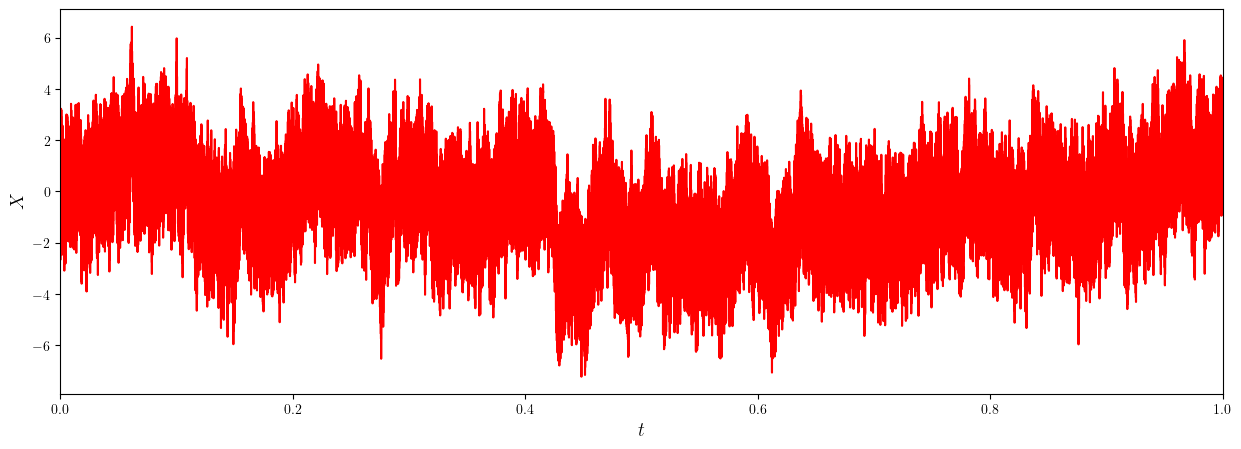

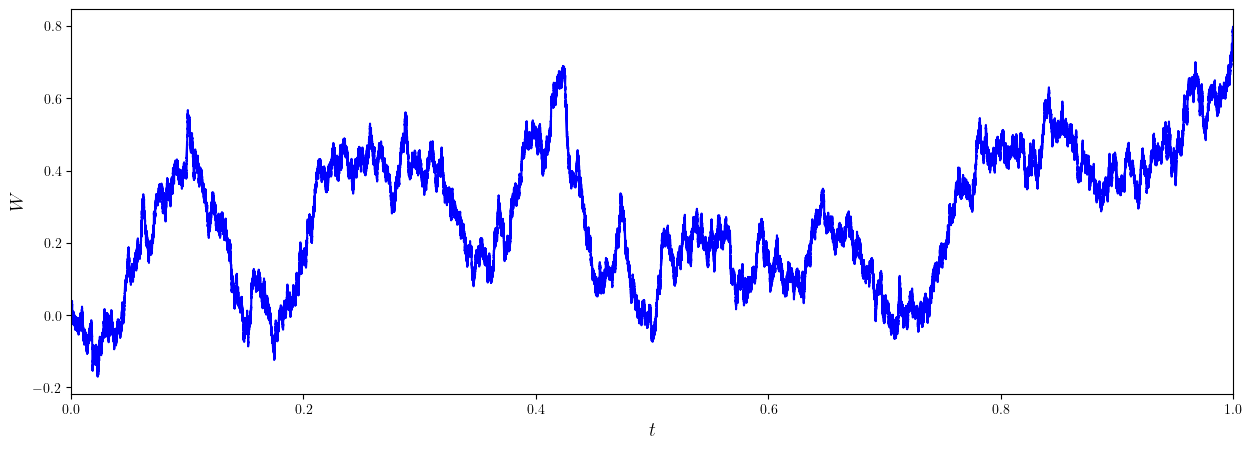

In [9]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'

plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$X$', fontsize=14)
pl_fbm = plt.plot(fine_times, fbm, color="red")

plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$W$', fontsize=14)
pl_bm = plt.plot(fine_times, bm, color="blue")


In [36]:
# Now that we have our "true noise", here are the parameters for subsampling from it
t0, t1 = 0, 1
epsilon = 0.001
lag = 1.2*epsilon
solver_epsilon = 0.1*epsilon
times = jnp.arange(t0, t1, epsilon)
every_nth_pt = int(grid_points*epsilon)
every_nth_pt

1000

In [37]:
# Create the controls; as before we subsample in order to test convergence (but this is only for testing purposes)
subsampled_bm = bm[::every_nth_pt]
bm_interp = LinearInterpolation(times, subsampled_bm[:])
bm_control = evaluate_and_reshape(bm_interp.evaluate)

subsampled_fbm = fbm[::every_nth_pt]
fbm_interp = LinearInterpolation(times, subsampled_fbm[:])
fbm_fun = evaluate_and_reshape_fun(fbm_interp.evaluate)
fbm_control = evaluate_and_reshape(fbm_interp.evaluate)
fbm_lagged_control = lagged_control(fbm_fun, lag)

lead_lag_control = join_controls(fbm_lagged_control, bm_control)

no_ll_control = join_controls(fbm_control, bm_control)

# check that they are similar to the original
#plt.figure(figsize=(20, 5))

#plt.plot(fine_times, fbm[:], color = 'red')
#plt.plot(times, subsampled_fbm[:], color = 'orange')

#plt.figure(figsize=(20, 5))

#plt.plot(fine_times, bm[:], color = 'blue')
#plt.plot(times, subsampled_bm[:], color = 'cyan')

The approximating ODEs read

$$ \begin{cases} \mathrm{d} S_t = \sqrt{a(Z_t - b)^2 + c} \, S_t \mathrm{d} W^{\varepsilon}_t - \frac{1}{2} \big[ \sigma_1 a S_t (a(Z_t - b)^2 + c)^{-1/2} (Z_t - b)Z_t^{\gamma_1} + (a(Z_t - b)^2 + c)S_t \big]\mathrm{d}t \\
\mathrm{d} Z_t = \sigma_0Z_t^{\gamma_0} \mathrm{d} X^\varepsilon_t + \sigma_1 Z_t^{\gamma_1} \mathrm{d} W_t^\varepsilon + (\alpha + \beta Z_t) \end{cases} $$

where $(X^\varepsilon, W^\varepsilon)$ is the lead-lag control (with $X$ lagged).

In [38]:
sigma0 = 0.1
sigma1 = 0.1

gamma0 = 1
gamma1 = 1

alpha = 0.1
beta = 0.1

a = 1
b = 0.1
c = 0.1

y0 = jnp.array([1, 1])
drift = lambda t, y, args: jnp.array([- (1/2) * sigma1 * a * y[0] * jnp.power(a*((y[1] - b)**2) + c, -1/2) * (y[1] - b) * jnp.power(y[1],gamma1) - (1/2) * (a*((y[1] - b)**2) + c) * y[0], alpha + beta * y[1]])
diffusion = lambda t, y, args: jnp.array([[0, jnp.sqrt(a*((y[1] - b)**2) + c) * y[0]], [sigma0 * jnp.power(y[1],gamma0), sigma1 * jnp.power(y[1],gamma1)]])
saveat = SaveAt(ts = times)
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, lead_lag_control))
terms_no_ll = MultiTerm(ODETerm(drift), ControlTerm(diffusion, no_ll_control))

In [39]:
solution_coarse = diffeqsolve(terms, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)
#solution_coarse_no_ll = diffeqsolve(terms_no_ll, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

In [33]:
# Now go back and take a finer discretisation, up to the cell before last

solution_fine = diffeqsolve(terms, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)
#solution_fine_no_ll = diffeqsolve(terms_no_ll, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

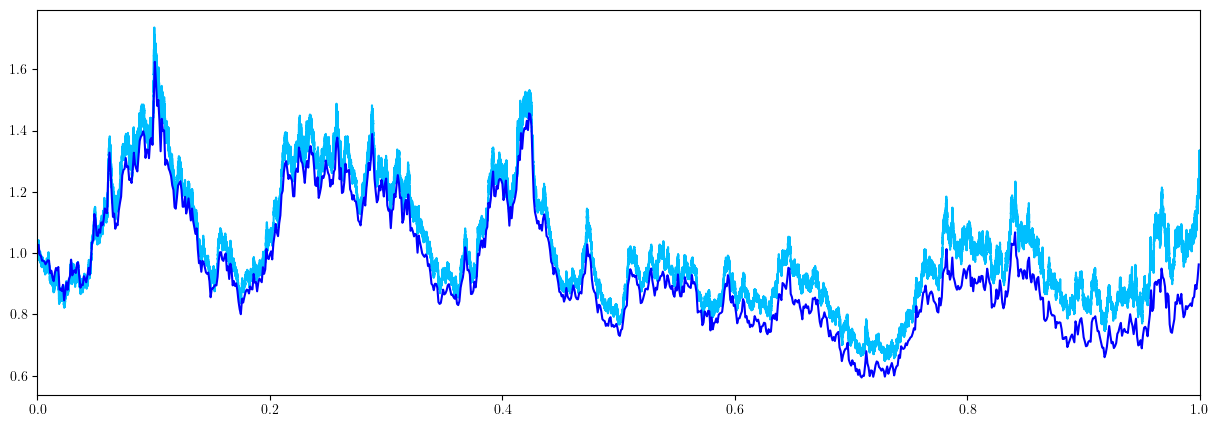

In [40]:
plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.plot(solution_fine.ts[:], solution_fine.ys[:, 0], color="deepskyblue", label='fine mesh')
plt.plot(solution_coarse.ts[:], solution_coarse.ys[:, 0], color="blue", label='coarse mesh')

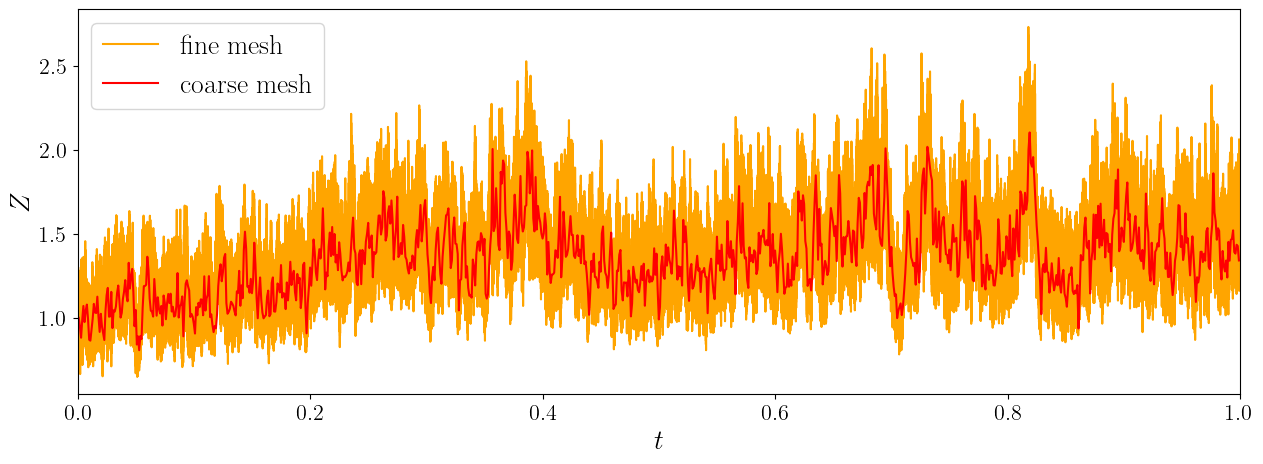

In [ ]:
# The comparison of fine-coarse plots for Z

plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=20)
plt.ylabel(r'$Z$', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.plot(solution_fine.ts[:], solution_fine.ys[:, 1], color = "orange", label='fine mesh')
plt.plot(solution_coarse.ts[:], solution_coarse.ys[:, 1], color = "red", label='coarse mesh')
plt.legend(loc='upper left', fontsize=20)
#plt.savefig('Z.pdf', bbox_inches='tight')

In [ ]:
# Now the plots for the price, including the difference on secondary y-axis

difference = solution_fine.ys[::2000, 0] - solution_coarse.ys[:, 0]

# Create the figure and the first y-axis
fig, ax1 = plt.subplots(figsize=(15, 5))

# Create the second y-axis
ax2 = ax1.twinx()

from matplotlib.ticker import MaxNLocator

# Plot data on the second y-axis first (with some opacity)
ax2.plot(solution_coarse.ts[:], difference, color="grey", alpha=0.5, label=r'$S^\mathrm{fine} - S^\mathrm{coarse}$')
ax2.set_ylabel(r'difference', fontsize=20, color="grey")  # LaTeX formatted y-axis label
ax2.tick_params(axis='y', labelcolor="grey", labelsize=16)
ax2.set_xlim(0, 1)  # Set x-axis limits to ensure the plot starts at 0 and ends at 1
#ax2.set_ylim(-0.11, 0.02)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=10))  # Add more ticks to the secondary y-axis
ax2.legend(loc='lower right', fontsize=20, bbox_to_anchor=(0.97, 0))

# Plot data on the first y-axis
ax1.plot(solution_fine.ts[:], solution_fine.ys[:, 0], color="deepskyblue", label='fine mesh')
ax1.plot(solution_coarse.ts[:], solution_coarse.ys[:, 0], color="blue", label='coarse mesh')
ax1.set_xlabel(r'$t$', fontsize=20)  # LaTeX formatted x-axis label
ax1.set_ylabel(r'$S$', fontsize=20, color="#007FFF")  # LaTeX formatted y-axis label
ax1.tick_params(axis='y', labelcolor="#007FFF", labelsize=16)
ax1.set_xlim(0, 1)  # Set x-axis limits to ensure the plot starts at 0 and ends at 1
ax1.legend(loc = 'lower left', fontsize=20)
#plt.savefig('S.pdf', bbox_inches='tight')


Now we check that both $Z$ and $S$ solved with the non lead-lagged control explode.

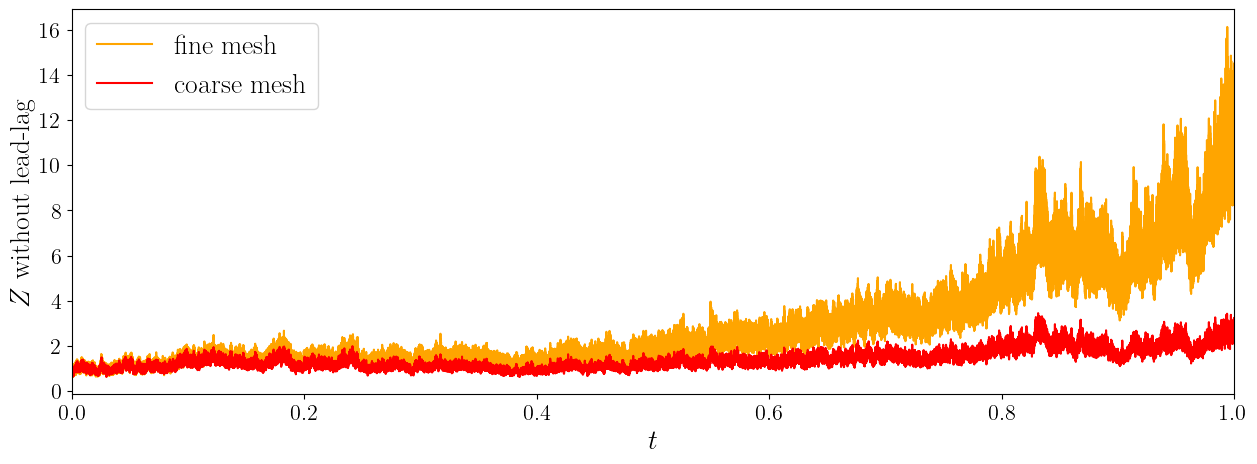

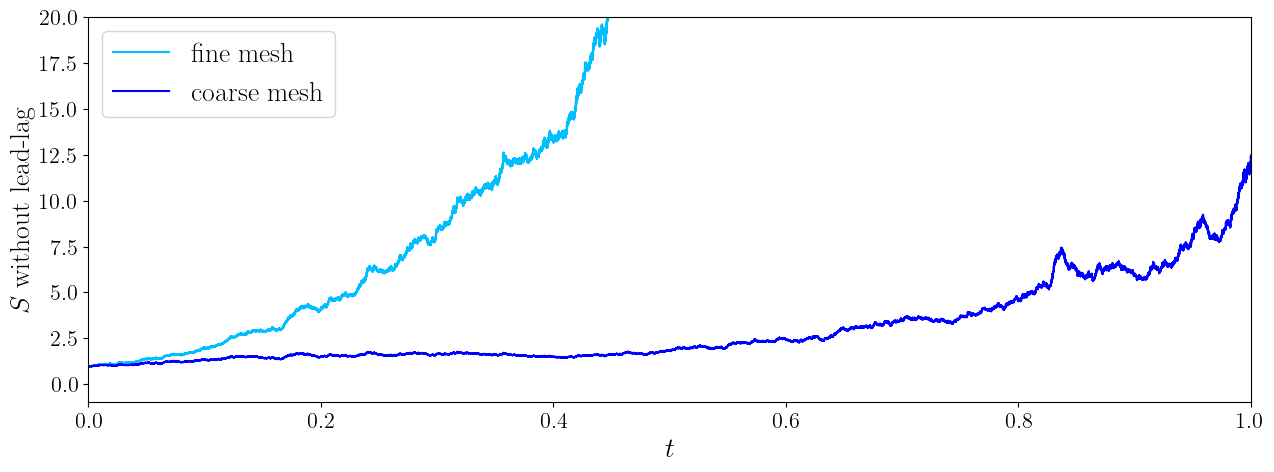

In [ ]:
import matplotlib.pyplot as plt

# Now let's observe divergence for the non lead-lagged case

plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=20)
plt.ylabel(r'$Z$ without lead-lag', fontsize=20)
plt.plot(solution_fine_no_ll.ts[:], solution_fine_no_ll.ys[:, 1], color="orange", label='fine mesh')
plt.plot(solution_coarse_no_ll.ts[:], solution_coarse_no_ll.ys[:, 1], color="red", label='coarse mesh')
plt.legend(loc='upper left', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.savefig('no_ll_Z.pdf', bbox_inches='tight')

plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=20)
plt.ylabel(r'$S$ without lead-lag', fontsize=20)
plt.ylim(-1, 20)
plt.plot(solution_fine_no_ll.ts[:], solution_fine_no_ll.ys[:, 0], color="deepskyblue", label='fine mesh')
plt.plot(solution_coarse_no_ll.ts[:], solution_coarse_no_ll.ys[:, 0], color="blue", label='coarse mesh')
plt.legend(loc='upper left', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
#plt.savefig('no_ll_S.pdf', bbox_inches='tight')

Let's check that the price coincides with the exponantial martingale

$$ S_t = \exp\bigg(\int_0^t\sqrt{a(Z_t - b)^2 + c\,} \mathrm{d}W - \frac 12 \int_0^t (a(Z_t - b)^2 + c) \mathrm{d}t \bigg) $$

In [325]:
solution = solution_fine
Z = LinearInterpolation(solution.ts[:], solution.ys[:, 1]).evaluate #create the vol process
y0 = jnp.array([0,0])
drift_exp = lambda t, y, args: jnp.array([-(1/2) * ( a * jnp.square(Z(t) - b) + c )])
diffusion_exp = lambda t, y, args: jnp.array([jnp.sqrt(a * jnp.square(Z(t) - b) + c)])
terms_exp = MultiTerm(ODETerm(drift_exp), ControlTerm(diffusion_exp, bm_interp))
integral_price = diffeqsolve(terms_exp, Euler(), 0, 1, dt0 = epsilon, max_steps=None, y0=y0, saveat=saveat) # note solver has to have size epsilon for this to be Ito
exp_martingale = jnp.exp(integral_price.ys[:])

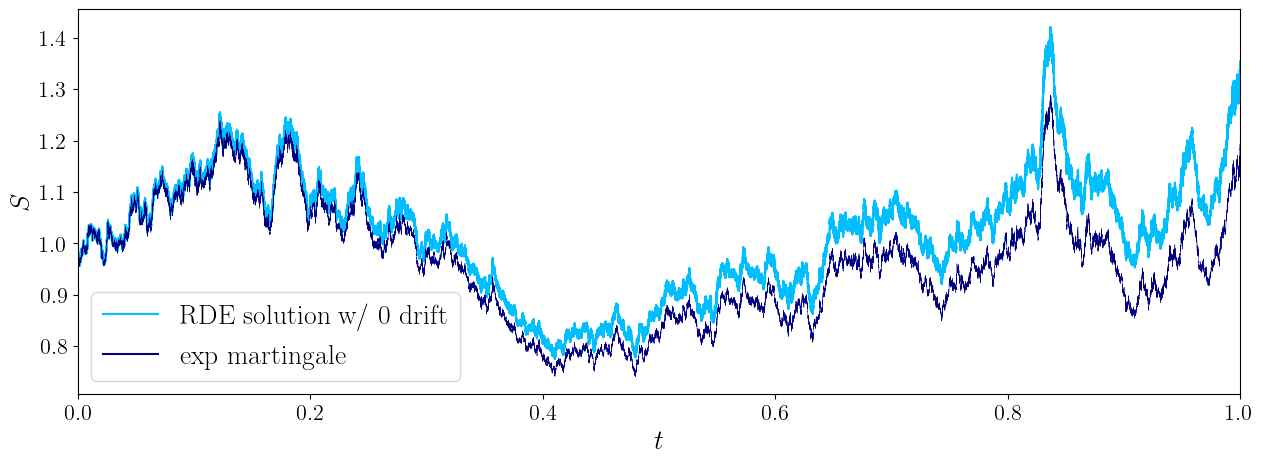

In [329]:
plt.figure(figsize=(15, 5))
plt.xlim(0, 1)
plt.xlabel(r'$t$', fontsize=20)
plt.ylabel(r'$S$', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Plot data and capture the line objects
line1 = plt.plot(solution.ts[:], solution.ys[:, 0], color="deepskyblue", label='RDE solution w/ 0 drift')[0]
line2 = plt.plot(integral_price.ts[:], exp_martingale[:], color="navy", linewidth=0.2)[0]

# Create custom legend handles
custom_line2 = plt.Line2D([], [], color="navy", label='exp martingale')

# Add a legend with the specified handles
plt.legend(handles=[line1, custom_line2], loc='lower left', fontsize=20)

plt.savefig('exp_mart_0_drift.pdf', bbox_inches='tight')
plt.show()

In [ ]:
diff_exp = solution.ys[:, 0] - exp_martingale[:,0]

# Create the figure and the first y-axis
fig, ax1 = plt.subplots(figsize=(15, 5))

# Create the second y-axis
ax2 = ax1.twinx()

from matplotlib.ticker import MaxNLocator

# Plot data on the second y-axis first (with some opacity)
ax2.plot(integral_price.ts[:], diff_exp, color="grey", alpha=0.5, label=r'$S^\mathrm{RDE} - S^\mathrm{exp}$')
ax2.set_ylabel(r'difference', fontsize=14, color="grey")  # LaTeX formatted y-axis label
ax2.tick_params(axis='y', labelcolor="grey")
ax2.set_xlim(0, 1)  # Set x-axis limits to ensure the plot starts at 0 and ends at 1
#ax2.set_ylim(-0.11, 0.02)
ax2.yaxis.set_major_locator(MaxNLocator(nbins=10))  # Add more ticks to the secondary y-axis
ax2.legend(loc = 'upper right')

plt.legend(loc='lower right')

# Plot data on the first y-axis
ax1.plot(solution_fine.ts[:], solution.ys[:, 0], color="deepskyblue", label='RDE solution')
ax1.plot(integral_price.ts[:], exp_martingale[:, 0], color="navy", label='exp martingale', linewidth = 0.4)
ax1.set_xlabel(r'$t$', fontsize=14)  # LaTeX formatted x-axis label
ax1.set_ylabel(r'$S$', fontsize=14, color="#007FFF")  # LaTeX formatted y-axis label
ax1.tick_params(axis='y', labelcolor="#007FFF")
ax1.set_xlim(0, 1)  # Set x-axis limits to ensure the plot starts at 0 and ends at 1
ax1.legend(loc = 'lower left')
plt.savefig('exp_diff.pdf', bbox_inches='tight')